In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset_copy import *
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
import jax
import jax.numpy as jnp
import equinox as eqx

def inv_softplus(y: jax.Array) -> jax.Array:
    return jnp.log(jnp.expm1(y))


class Example(TripletModel):
    # unconstrained trainable parameters for 2x2 lower-triangular factor
    K: jax.Array

    def __init__(self, der_K: jax.Array, key: jax.Array):
        """
        der_K is the user-facing physical 3-vector:
            [k_ss, k_sb, k_bb]

        We convert it to unconstrained parameters of a Cholesky factor L
        so that the induced 2x2 matrix B = L L^T is always symmetric PSD.
        """
        der_K = jnp.ravel(der_K)
        if der_K.shape != (3,):
            raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")

        k_ss0, k_sb0, k_bb0 = der_K
        eps = 1e-6

        # PSD condition for
        # [[k_ss, sqrt(2) k_sb],
        #  [sqrt(2) k_sb, k_bb]]
        if (k_ss0 < 0) or (k_bb0 < 0) or (k_ss0 * k_bb0 - 2.0 * k_sb0**2 < 0):
            raise ValueError(
                "Initial [k_ss, k_sb, k_bb] must satisfy PSD condition: "
                "k_ss >= 0, k_bb >= 0, and k_ss*k_bb - 2*k_sb^2 >= 0."
            )

        # Convert physical coefficients to Cholesky factor entries
        l11 = jnp.sqrt(jnp.maximum(k_ss0, eps))
        l21 = jnp.sqrt(2.0) * k_sb0 / l11
        rem = k_bb0 - l21**2
        l22 = jnp.sqrt(jnp.maximum(rem, eps))

        # Store unconstrained parameters
        p0 = inv_softplus(l11 - eps)
        p1 = l21
        p2 = inv_softplus(l22 - eps)

        self.K = jnp.array([p0, p1, p2])

    def _vec_to_L(self, p: jax.Array) -> jax.Array:
        eps = 1e-6
        p = jnp.ravel(p)
        return jnp.array([
            [jax.nn.softplus(p[0]) + eps, 0.0],
            [p[1],                        jax.nn.softplus(p[2]) + eps],
        ])

    def get_K_entries(self) -> jax.Array:
        """
        Returns the physical coefficients [k_ss, k_sb, k_bb], guaranteed PSD.
        """
        L = self._vec_to_L(self.K)
        B = L @ L.T

        # B = [[k_ss, sqrt(2) k_sb],
        #      [sqrt(2) k_sb, k_bb]]
        k_ss = B[0, 0]
        k_sb = B[0, 1] / jnp.sqrt(2.0)
        k_bb = B[1, 1]

        return jnp.array([k_ss, k_sb, k_bb])

    def get_K_matrix(self) -> jax.Array:
        """
        Full structured stiffness matrix acting on [e0, e1, eb]:
            [[k_ss,   0,   k_sb],
             [  0,  k_ss,  k_sb],
             [k_sb, k_sb,  k_bb]]
        """
        k_ss, k_sb, k_bb = self.get_K_entries()
        return jnp.array([
            [k_ss, 0.0,  k_sb],
            [0.0,  k_ss, k_sb],
            [k_sb, k_sb, k_bb],
        ])

    def __call__(self, del_strain):
        del_strain = jnp.ravel(del_strain)

        e0 = del_strain[0]
        e1 = del_strain[1]
        eb = del_strain[3]

        k_ss, k_sb, k_bb = self.get_K_entries()

        stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
        coupling_energy = k_sb * (e0 + e1) * eb
        bending_energy = 0.5 * k_bb * eb**2

        return stretching_energy + coupling_energy + bending_energy

In [3]:
train_datafile = "experiment_data/train.npz"
valid_datafile = "experiment_data/valid.npz"

init_K=jnp.array([0.1, 0.001, 0.05])
validate_model(Example, der_K=init_K)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=500, lr=1e-2, init_K=init_K )

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

Initial training loss: 1.00787e-04
K: [-0.98901915  0.00447214 -1.3842085 ]
grad K: [3.42313964e-05 1.07980000e-04 1.47483977e-04]
loss finite? True
grad finite? True
Step 0    | LR: 1.000e-02  | Train: 1.00787e-04  | Valid: 9.71499e-05  | K: [-0.99901623 -0.00552694 -1.39420782]
Step 10   | LR: 9.991e-03  | Train: 8.11884e-05  | Valid: 7.88475e-05  | K: [-1.09899313 -0.01617258 -1.49406611]
Step 20   | LR: 9.965e-03  | Train: 6.13473e-05  | Valid: 5.82243e-05  | K: [-1.20034262 -0.00822609 -1.595494  ]
Step 30   | LR: 9.921e-03  | Train: 4.12131e-05  | Valid: 3.72431e-05  | K: [-1.30226756  0.00421641 -1.69726854]
Step 40   | LR: 9.859e-03  | Train: 2.28130e-05  | Valid: 1.94435e-05  | K: [-1.4017935   0.00420106 -1.79663697]
Step 50   | LR: 9.781e-03  | Train: 9.33577e-06  | Valid: 7.19938e-06  | K: [-1.49397939  0.00586695 -1.88669735]
Step 60   | LR: 9.685e-03  | Train: 2.75877e-06  | Valid: 2.12129e-06  | K: [-1.57266112  0.00277781 -1.95658217]
Step 70   | LR: 9.573e-03  | Train:

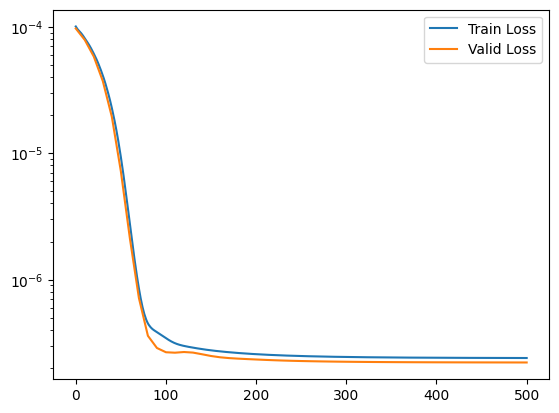

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
from util_multiset_copy import TestCase

train = TestCase.from_npz(train_datafile)
valid = TestCase.from_npz(valid_datafile)


print("train.qs finite:", jnp.all(jnp.isfinite(train.qs)))
print("train.xb finite:", jnp.all(jnp.isfinite(train.xb)))
print("train.lambdas finite:", True if train.lambdas is None else jnp.all(jnp.isfinite(train.lambdas)))

print("valid.qs finite:", jnp.all(jnp.isfinite(valid.qs)))
print("valid.xb finite:", jnp.all(jnp.isfinite(valid.xb)))
print("valid.lambdas finite:", True if valid.lambdas is None else jnp.all(jnp.isfinite(valid.lambdas)))


train.qs finite: True
train.xb finite: True
train.lambdas finite: True
valid.qs finite: True
valid.xb finite: True
valid.lambdas finite: True


In [6]:
# base, aux, der = get_base_rod()
# train = TestCase.from_npz(train_datafile)

# model = Example(der_K=jnp.array([0.1, 0.05]), key=jax.random.PRNGKey(42))
# debug_dataset_loss(model, base, aux, train)

In [7]:
def make_bc_from_testcase(dataset, i=None):
    lambdas = dataset.lambdas if dataset.lambdas is not None else jnp.linspace(0.0, 1.0, dataset.qs.shape[1])

    if i is None:
        idx_b = dataset.idx_b
        xb = dataset.xb
    else:
        idx_b = dataset.idx_b if dataset.idx_b.ndim == 1 else dataset.idx_b[i]
        xb = dataset.xb[i]

    print("xb.shape", xb.shape)
    return djx.BatchedDirectBC(
        idx_b=idx_b,
        xb=xb,
        lambdas=lambdas,
    )

In [8]:
print("valid.xb.shape", valid.xb.shape)
lambdas = valid.lambdas if valid.lambdas is not None else jnp.linspace(0.0, 1.0, valid.qs.shape[1])
base, aux, _ = get_base_rod()
bc = make_bc_from_testcase(valid)
rod = base.with_bc(bc)
pred = rod.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print("pred.shape", pred.shape)
print("valid.qs.shape", valid.qs.shape)
print("train.qs.shape", train.qs.shape)
# animate(pred)

valid.xb.shape (2, 10, 8)
xb.shape (2, 10, 8)
pred.shape (2, 10, 11)
valid.qs.shape (2, 10, 11)
train.qs.shape (2, 10, 11)


In [9]:
# animate(valid.qs)

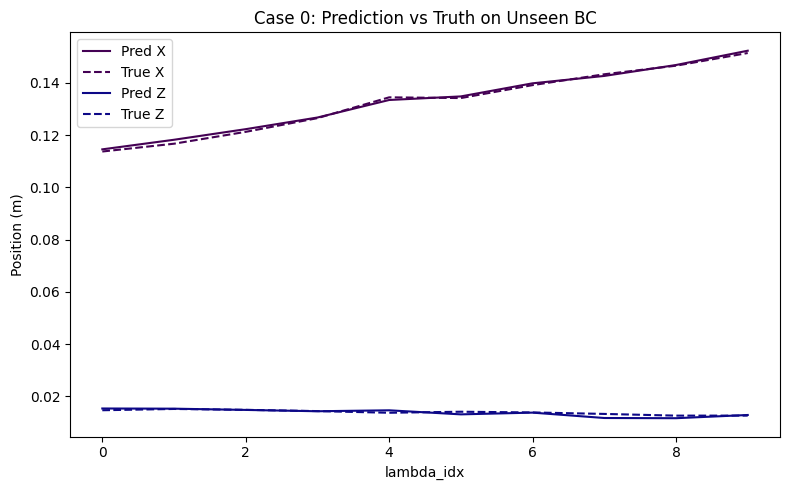

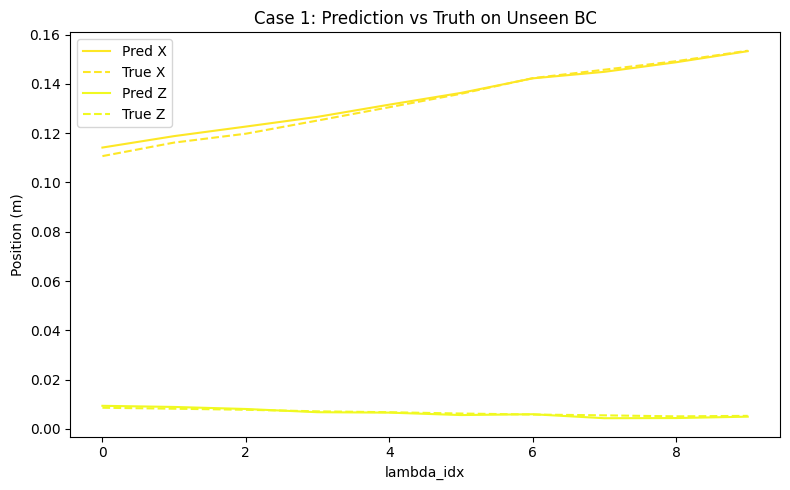

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import jax.numpy as jnp

n_cases = pred.shape[0]

# one colormap per coordinate
colors_x = cm.viridis(jnp.linspace(0, 1, n_cases))
colors_z = cm.plasma(jnp.linspace(0, 1, n_cases))

for i in range(n_cases):
    cx = colors_x[i]
    cz = colors_z[i]

    fig, ax = plt.subplots(figsize=(8, 5))

    # X coordinate
    ax.plot(pred[i, :, 4], color=cx, linestyle='-', label='Pred X')
    ax.plot(valid.qs[i, :, 4], color=cx, linestyle='--', label='True X')

    # Z coordinate
    ax.plot(pred[i, :, 6], color=cz, linestyle='-', label='Pred Z')
    ax.plot(valid.qs[i, :, 6], color=cz, linestyle='--', label='True Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [11]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[0.         0.         0.         0.         0.11300349 0.
  0.01657482 0.         0.23382102 0.         0.13500646]
 [0.         0.         0.         0.         0.10997066 0.
  0.01648045 0.         0.22677252 0.         0.13321703]]
final:  [[0.         0.         0.         0.         0.11143794 0.
  0.01026583 0.         0.23206285 0.         0.11900306]
 [0.         0.         0.         0.         0.10697546 0.
  0.01032906 0.         0.22445548 0.         0.11741954]]
Validation BC:
init:  [[0.         0.         0.         0.         0.14655865 0.
  0.01259217 0.         0.29649265 0.         0.12744382]
 [0.         0.         0.         0.         0.15141125 0.
  0.01260447 0.         0.30737344 0.         0.13081271]]
final:  [[0.         0.         0.         0.         0.14919935 0.
  0.00509007 0.         0.30000829 0.         0.11267491]
 [0.         0.         0.         0.         0.15346497 0.
  0.00529648 0.         0.30894686 0.         0.11458

In [12]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[0.         0.         0.         0.         0.13277641 0.
  0.01725533 0.         0.26653386 0.         0.13789818]
 [0.         0.         0.         0.         0.12705972 0.
  0.01727204 0.         0.25443739 0.         0.13331234]
 [0.         0.         0.         0.         0.12212673 0.
  0.01723858 0.         0.24612272 0.         0.13362513]]
final position of the middle node in the training data:  [[0.         0.         0.         0.         0.1312469  0.
  0.01043344 0.         0.26560806 0.         0.12132298]
 [0.         0.         0.         0.         0.12613359 0.
  0.01047439 0.         0.25672117 0.         0.12172881]
 [0.         0.         0.         0.         0.12149112 0.
  0.010437   0.         0.24942622 0.         0.12254084]]


In [13]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[0.         0.         0.         0.         0.13444641 0.
  0.01368943 0.         0.27034087 0.         0.13141174]
 [0.         0.         0.         0.         0.13416888 0.
  0.01408874 0.         0.27294775 0.         0.12834982]
 [0.         0.         0.         0.         0.13912665 0.
  0.01381549 0.         0.28279979 0.         0.13075516]]
final position of the middle node in the validation data:  [[0.         0.         0.         0.         0.13052639 0.
  0.00677359 0.         0.2663429  0.         0.11360569]
 [0.         0.         0.         0.         0.13598007 0.
  0.00624168 0.         0.27560766 0.         0.11266652]
 [0.         0.         0.         0.         0.1423159  0.
  0.00583113 0.         0.28722089 0.         0.11468523]]


In [14]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[0.         0.         0.         0.         0.13343039 0.
  0.01463151 0.         0.27034087 0.         0.13141174]
 [0.         0.         0.         0.         0.13480076 0.
  0.01307848 0.         0.27294775 0.         0.12834982]
 [0.         0.         0.         0.         0.139814   0.
  0.01374168 0.         0.28279979 0.         0.13075516]]
final position of the middle node in the prediction:  [[0.         0.         0.         0.         0.13157098 0.
  0.00660968 0.         0.2663429  0.         0.11360569]
 [0.         0.         0.         0.         0.13633612 0.
  0.00562272 0.         0.27560766 0.         0.11266652]
 [0.         0.         0.         0.         0.14224707 0.
  0.00595466 0.         0.28722089 0.         0.11468523]]
